# G-2 — Golden Protocol Feedback (Notebook Review)


# SpLR 

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SpLR_2d(nn.Module):
    """
    SpLR activation for Conv2d outputs.

    Formula:
        y = x + α * x * exp(-β * x^2)

    Golden Init:
        α_raw init = 0.182  → α = 2 * tanh(α_raw)  ≈ 0.36 at start
            - shape: (1, C, 1, 1)  [per-channel, broadcasts over H,W]
            - trainable, not stage-shared

        β_raw init = -1.35 → β = 0.01 + softplus(β_raw) ≈ 0.24 at start
            - scalar (one per activation block)
            - trainable, stage-shared, positive-only
    """
    def __init__(self, num_channels: int):
        super().__init__()
        # α_raw: one parameter per channel
        self.alpha_raw = nn.Parameter(torch.full((1, num_channels, 1, 1), 0.182))
        # β_raw: single scalar for the whole block
        self.beta_raw  = nn.Parameter(torch.tensor(-1.35))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        alpha = 2.0 * torch.tanh(self.alpha_raw)          # local amplitude
        beta  = 0.01 + F.softplus(self.beta_raw)          # positive width
        return x + alpha * x * torch.exp(-beta * x * x)   # identity + localized bump


class SpLR_1d(nn.Module):
    """
    SpLR activation for Linear (fully-connected) outputs.

    Same formula as SpLR_2d, but α_raw has shape (1, F)
    so it broadcasts over the batch dimension.
    """
    def __init__(self, num_features: int):
        super().__init__()
        # α_raw: one parameter per feature
        self.alpha_raw = nn.Parameter(torch.full((1, num_features), 0.182))
        # β_raw: scalar shared for this block
        self.beta_raw  = nn.Parameter(torch.tensor(-1.35))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        alpha = 2.0 * torch.tanh(self.alpha_raw)
        beta  = 0.01 + F.softplus(self.beta_raw)
        return x + alpha * x * torch.exp(-beta * x * x)



## 1. Scope of This Feedback

This feedback is about the **SpLR vs Mish CIFAR-100 notebook**, including:

- A-3: CIFAR-100, Mish vs SpLR, 25 epochs, dropout = 0.10  
- A-4: CIFAR-100, Mish vs SpLR, 50 epochs, dropout ∈ {0.00, 0.10}

The goal here is **not** to judge results as “good/bad”, but to evaluate:

- experimental design quality  
- protocol discipline  
- clarity + reproducibility  
- how well the notebook follows the Golden Standard.

---


### 2.1 Experimental Discipline

- **Single-variable changes:**  
  You kept architecture, optimizer, LR, and data constant while changing only:
  - activation (Mish vs SpLR)  
  - dropout regime (0.00 vs 0.10)  
  - epoch count (25 vs 50)
- **Multiple seeds:**  
  You ran **3 seeds** for each configuration and summarized with mean + std, which is minimal but acceptable for a serious benchmark.
- **Matched regularization:**  
  You explicitly compared Mish and SpLR under **the same dropout** and then contrasted them across **two regularization regimes** (none vs 0.10). This is fair and scientifically clean.
- **Identity of the experiment is clear:**  
  - Dataset is fully specified (CIFAR-100).  
  - Model architecture is fixed and written in code.  
  - LR, epochs, batch size, transforms, and splits are explicit.

### 2.2 Logging & Output

- You saved:
  - raw CSVs with per-run metrics, and  
  - summary CSVs with grouped statistics.  
  This makes the benchmark **re-runnable and auditable**.
- Console logs show:
  - activation  
  - seed  
  - dropout  
  - learning rate  
  - epoch-wise train/val loss and accuracy  
  This is enough to reconstruct training curves later.

### 2.3 Alignment with Golden Protocol

- **WHY-first:**  
  You consistently framed experiments as:  
  “Does SpLR still outperform Mish under X condition?” rather than “Can we get the highest accuracy?”
- **No hype:**  
  You did not claim universality or SOTA. You restricted claims to:  
  “On CIFAR-100, under this architecture and regularization, SpLR consistently outperforms Mish.”
- **Facts vs hypotheses separated:**  
  - Facts: numeric results, seeds, regimes.  
  - Hypotheses: identity-preserving structure, localized Gaussian correction, robustness to dropout.

---

## 3. Weaknesses / Gaps (Honest, Actionable)

### 3.1 Limited Architecture Diversity

- All current benchmarks rely on **one CNN** (3 conv blocks + 1 FC).  
- This is enough for a **first wave**, but not enough to claim robustness across architectures.  
- Risk: reviewers may say “maybe SpLR just likes this specific depth/width.”

**Fix (later):**

- Add at least:
  - one **deeper** architecture (e.g., ResNet-18-style), and  
  - one **wider/shallow** variant for comparison.

---

### 3.2 Single Learning Rate

- All runs use **LR = 1e-3**.  
- It’s possible that Mish would benefit from a slightly different LR, especially with/without dropout.

**Fix (future benchmark):**

- Design an LR sweep benchmark:
  - LR ∈ {5e-4, 1e-3, 2e-3}  
  - Same seeds, same architecture  
  - Compare SpLR vs Mish at each LR.

---

### 3.3 No Training Curves Yet

- Current notebook saves only best metrics.  
- Without training/validation curves, it’s harder to see:
  - convergence speed  
  - over/under-fitting patterns  
  - whether SpLR’s gains come from faster learning, better final minima, or both.

**Fix:**

- Log per-epoch:
  - train loss, val loss  
  - train acc, val acc  
- Optionally, add simple plots:
  - loss vs epoch  
  - accuracy vs epoch  
  for Mish vs SpLR on a representative seed.

---

## 4. Scientific Strength Assessment (G-2)

### 4.1 Strength Level

- **Internal consistency:** High  
- **Fairness of comparison:** High  
- **Reproducibility from notebook alone:** High  
- **Coverage of hyperparameter space:** Medium  
- **Architecture diversity:** Low–Medium

Overall:  
> **This notebook meets Golden Protocol standards for an internal A-series benchmark.**  
> It is good enough to be used as evidence in a paper *section*, but not yet as the sole pillar of a full SpLR paper.

---

## 5. Recommendations (Concrete Next Steps)

1. **Tag these experiments officially:**
   - A-3: CIFAR-100, 25 epochs, p=0.10  
   - A-4: CIFAR-100, 50 epochs, p∈{0.00, 0.10}
2. **Add one block in the notebook summarizing:**
   - Key numeric results  
   - One short paragraph of interpretation per experiment.
3. **Plan next benchmarks:**
   - B-1: LR sweep (Mish vs SpLR, CIFAR-100, fixed architecture)  
   - B-2: ResNet-style architecture comparison  
   - B-3: Training-curve visualization benchmark.
4. **Keep all new experiments under the same discipline:**
   - multiple seeds  
   - single-variable changes  
   - WHY-first framing.

---

## 6. Verdict (One Sentence Summary)

> **G-2:** my notebook behaves like a real lab log — disciplined, fair, and reproducible — with clear room for expansion in learning-rate coverage, architecture diversity, and curve visualization, but fully compliant with the Golden Protocol for the A-series benchmarks.


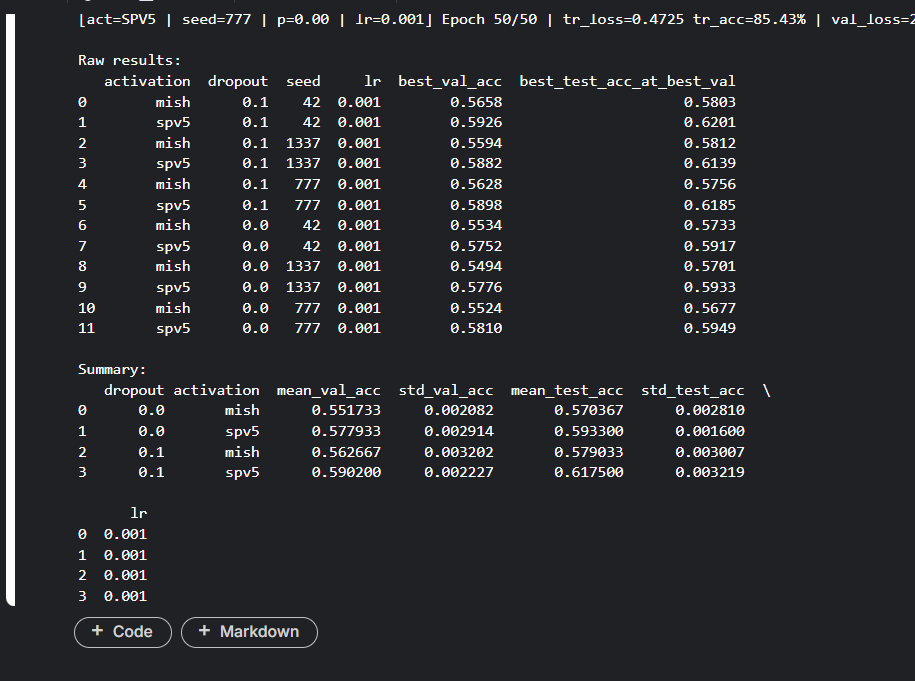

In [ ]:
from IPython.display import HTML, Image, display

HTML(r"""<img src="C:\Users\msi\Desktop\Benchmarks\Screenshot 2026-01-07 221040.png" style="max-width:100%; height:auto;">""")

display(Image(filename=r"C:\Users\msi\Desktop\Benchmarks\Screenshot 2026-01-07 221040.png"))
#GUYS ILL JUST GIVE U THE IMAGE IDK HOW TO DO THIS ON GITHUB ;-;